# Recommendation Generation

This notebook replicates the diagnostic *agents* from Nori et al. (2025), *Sequential
Diagnosis with Language Models*, running them over the EHR-based environment from the
previous notebook. It builds up in two steps:

1. **Baseline agent** - the paper's minimal prompt (their Figure 4), where the model
   emits `<question>`, `<test>`, and `<diagnosis>` tags. This is the "out-of-the-box"
   control.
2. **MAI-DxO panel** - one model call role-plays a five-physician virtual panel
   (Hypothesis, Test-Chooser, Challenger, Stewardship, Checklist) that deliberates in a
   *Chain of Debate* before committing to a single action each turn.

Running both on the same cases is how the paper isolates the accuracy and cost effect of
the orchestration, holding the underlying model fixed.

## Where this sits in the pipeline

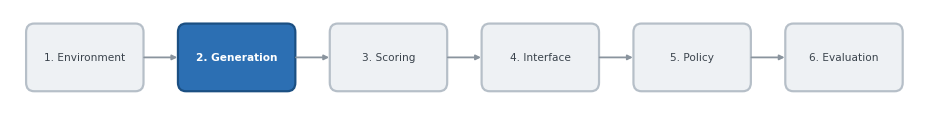

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../01_environment'))
from shared.diagrams import draw_pipeline, draw_sdbench_loop
draw_pipeline(active='generation');

## How it works

The agent (baseline or panel) is the highlighted box. Each turn it issues one action to
the Gatekeeper, which returns a finding and adds its cost. When the agent commits a
diagnosis, the Judge scores it against the record's ICD ground truth. Generation is
specifically the *policy that chooses each action* - everything else is the environment
from Notebook 01.

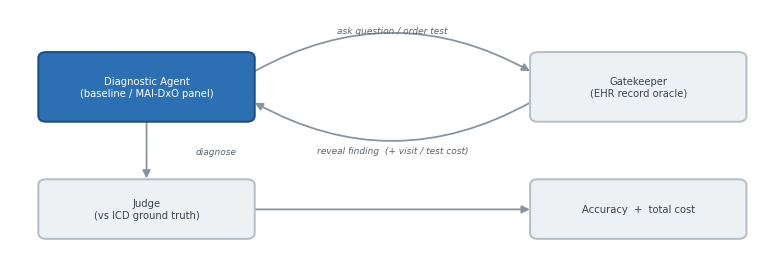

In [2]:
draw_sdbench_loop(highlight='agent');

## The two prompts

The only thing that differs between the agents is how they are instructed. Read both
prompts before running them - the baseline asks for a single tagged action; the panel
asks one model to play five roles and return a structured deliberation.

In [3]:
from shared import llm
import demo_generation as gen

print('Backend:', llm.detect_backend(), '|', llm.active_model())
print('\n=== BASELINE prompt (paper Fig 4) ===\n')
print(gen.BASELINE_SYSTEM)

Backend: openrouter | openrouter:meta-llama/llama-3.3-70b-instruct

=== BASELINE prompt (paper Fig 4) ===

You are a diagnostic assistant working a case sequentially. Each turn, take ONE of these actions using XML tags:
  <question>ask the patient/record one history or exam question</question>
  <test>order one named diagnostic test (labs, imaging, micro)</test>
  <diagnosis>commit your single final diagnosis</diagnosis>
Order tests by exact name. Do not mix tags. Gather enough evidence, then diagnose.


In [4]:
print('=== MAI-DxO panel prompt (paper Sec 3.2) ===\n')
print(gen.PANEL_SYSTEM)

=== MAI-DxO panel prompt (paper Sec 3.2) ===

You ARE a virtual panel of five physicians deliberating on one case, as in the MAI Diagnostic Orchestrator. Internally adopt all five roles each turn:
  - Dr. Hypothesis: maintain a probability-ranked differential (top 3), update it Bayesian-style.
  - Dr. Test-Chooser: pick the test that best discriminates between the leading hypotheses.
  - Dr. Challenger: name the most likely anchoring error and a test that could falsify the lead.
  - Dr. Stewardship: prefer cheaper equivalent tests; veto low-yield expensive ones.
  - Dr. Checklist: ensure the chosen test name is valid and the plan is consistent.
After a brief chain of debate, COMMIT to exactly one action this turn.
Respond with ONLY JSON: {"differential": [{"dx": str, "p": float}], "debate": str, "action": "ask"|"test"|"diagnose", "query": str|null, "diagnosis": str|null}


> To run a real model instead of the offline stub, copy `../.env.example` to `../.env`
> and set `OPENROUTER_API_KEY` (any model via `OPENROUTER_MODEL`), or run a local Ollama
> model. With the stub, both agents follow the same deterministic policy; with a real
> model they diverge on which tests they order and when they commit.

## 1. Baseline agent
Watch it ask, order tests, and commit, accumulating cost as it goes.

In [5]:
baseline_result = gen.run_baseline('PE-2180')

--------------------------------------------------------------------------------
BASELINE | case PE-2180 | model = openrouter:meta-llama/llama-3.3-70b-instruct
--------------------------------------------------------------------------------
  test     D-Dimer  (+$40)
  test     CT pulmonary angiogram  (+$500)
  test     Chest radiograph  (+$60)
  question Can you describe the severity of your dyspnea and whet  (+$300)
  diagnose -> Pulmonary embolism
    Judge: CORRECT | matched tokens=['embolism', 'pulmonary'] vs principal dx='Other pulmonary embolism without acute cor pulmonale'
  SUMMARY: turns=5  cost=$900  dx='Pulmonary embolism'  correct=True



## 2. MAI-DxO panel
Same case, same environment. Note the per-turn differential and the panel's stated
reasoning before each action.

In [6]:
panel_result = gen.run_panel('PE-2180')

--------------------------------------------------------------------------------
MAI-DxO PANEL | case PE-2180 | model = openrouter:meta-llama/llama-3.3-70b-instruct
--------------------------------------------------------------------------------
  differential: Pulmonary Embolism (0.6), Pneumothorax (0.2), Acute Coronary Syndrome (0.2)
  debate: Dr. Hypothesis prioritizes Pulmonary Embolism due to recent long-haul flight. Dr. Test-Cho
  -> TEST: D-Dimer  (+$40)

  differential: Pulmonary Embolism (0.7), Pneumothorax (0.2), Acute Coronary Syndrome (0.1)
  debate: Dr. Hypothesis: Given the patient's symptoms and elevated D-Dimer, Pulmonary Embolism is t
  -> TEST: Chest radiograph  (+$60)

  differential: Pulmonary Embolism (0.7), Pneumothorax (0.2), Acute Coronary Syndrome (0.1)
  debate: Dr. Hypothesis prioritizes Pulmonary Embolism due to the patient's recent long-haul flight
  -> TEST: CT pulmonary angiogram  (+$500)

  differential: Pulmonary Embolism (0.8), Pneumonia (0.1), Acute C

## 3. Compare both agents across cases
Accuracy and cost are the two SDBench axes. With a real model this table is where the
panel's effect shows up.

In [7]:
from shared.toy_data import all_cases

print(f"{'case':<12}{'agent':<10}{'correct':<9}{'cost':<8}{'turns'}")
for case in all_cases():
    for name, fn in [('baseline', gen.run_baseline), ('panel', gen.run_panel)]:
        import io, contextlib
        with contextlib.redirect_stdout(io.StringIO()):
            r = fn(case.case_id)
        print(f"{case.case_id:<12}{name:<10}{str(r['correct']):<9}${r['cost']:<7.0f}{r['turns']}")

case        agent     correct  cost    turns
PE-2180     baseline  True     $840    6
PE-2180     panel     True     $640    5
DKA-3391    baseline  True     $710    8
DKA-3391    panel     True     $300    8
URO-4477    baseline  True     $1370   8
URO-4477    panel     True     $605    7


## Notes for extension
- The paper evaluates five cost variants (Instant Answer -> Question-Only -> Budgeted ->
  Unconstrained -> Ensemble). The panel here is the "unconstrained" form; a budget tracker
  and an ensemble wrapper are the natural next variants.
- Swapping `OPENROUTER_MODEL` lets you reproduce their cross-family comparison
  (GPT, Claude, Gemini, Llama, ...).

**Next:** Notebook 03 scores each generated recommendation for appropriateness and harm.